<a href="https://colab.research.google.com/github/SHUBHI289/Celebal-Technologies-training/blob/main/Week5_Shubhi_Gupta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Project

# Text Generation using Vanilla RNN, LSTM and GRU

## Aim

The aim of this project is to understand how different recurrent neural network architectures such as Vanilla RNN, LSTM, and GRU learn the structure of a text corpus and generate meaningful text by predicting the next word.

---

## Problem Statement

Design and implement deep learning models capable of learning grammar, sentence flow, and contextual dependencies from a text corpus using:

- Vanilla RNN
- LSTM
- GRU

Finally, compare the models based on:

- Training Loss
- Generated Text Quality
- Memory Handling
- Long-Term Dependency Learning

## Import Required Libraries

In this step, I am importing all the libraries required for preprocessing the text, building the deep learning models, and visualizing the results.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import re

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## Load the Text Corpus

For this project, I am using a small custom text corpus. This helps the models learn sentence structure quickly and makes the notebook easy to execute.

In [2]:
corpus = """
Artificial Intelligence is changing many industries today.
Deep learning helps machines learn from large amounts of data.
Recurrent Neural Networks are useful for sequence prediction tasks.
LSTM networks remember important information for a longer time.
GRU networks are simpler and faster than LSTM while giving similar performance.
Text generation predicts one word at a time based on previous words.
Machine learning models improve as they are trained on more examples.
Natural language processing helps computers understand human language.
"""

## Clean the Text

Before training the models, I convert all the text into lowercase letters and remove punctuation marks. This helps reduce unnecessary variations in the vocabulary.

In [3]:
corpus = corpus.lower()

corpus = re.sub(r'[^a-z\s]', '', corpus)

print(corpus)


artificial intelligence is changing many industries today
deep learning helps machines learn from large amounts of data
recurrent neural networks are useful for sequence prediction tasks
lstm networks remember important information for a longer time
gru networks are simpler and faster than lstm while giving similar performance
text generation predicts one word at a time based on previous words
machine learning models improve as they are trained on more examples
natural language processing helps computers understand human language



## Tokenization

Deep learning models cannot understand raw text directly. Therefore, I use a tokenizer to assign a unique integer to every unique word present in the corpus.

In [4]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

print(tokenizer.word_index)

Vocabulary Size: 67
{'networks': 1, 'are': 2, 'learning': 3, 'helps': 4, 'for': 5, 'lstm': 6, 'a': 7, 'time': 8, 'on': 9, 'language': 10, 'artificial': 11, 'intelligence': 12, 'is': 13, 'changing': 14, 'many': 15, 'industries': 16, 'today': 17, 'deep': 18, 'machines': 19, 'learn': 20, 'from': 21, 'large': 22, 'amounts': 23, 'of': 24, 'data': 25, 'recurrent': 26, 'neural': 27, 'useful': 28, 'sequence': 29, 'prediction': 30, 'tasks': 31, 'remember': 32, 'important': 33, 'information': 34, 'longer': 35, 'gru': 36, 'simpler': 37, 'and': 38, 'faster': 39, 'than': 40, 'while': 41, 'giving': 42, 'similar': 43, 'performance': 44, 'text': 45, 'generation': 46, 'predicts': 47, 'one': 48, 'word': 49, 'at': 50, 'based': 51, 'previous': 52, 'words': 53, 'machine': 54, 'models': 55, 'improve': 56, 'as': 57, 'they': 58, 'trained': 59, 'more': 60, 'examples': 61, 'natural': 62, 'processing': 63, 'computers': 64, 'understand': 65, 'human': 66}


## Create N-gram Sequences

The next-word prediction problem is created using N-gram sequences.

For example,

Deep Learning

becomes

- Deep Learning
- Deep Learning Helps
- Deep Learning Helps Machines

Each sequence uses all previous words to predict the next word.

In [5]:
input_sequences = []

for line in corpus.split("\n"):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):

        n_gram_sequence = token_list[:i + 1]

        input_sequences.append(n_gram_sequence)

## Pad the Sequences

Since every sequence has a different length, I pad them with zeros at the beginning so that all input sequences have the same length.

In [6]:
max_len = max(len(sequence) for sequence in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding="pre"
)

print("Maximum Sequence Length:", max_len)

Maximum Sequence Length: 12


## Prepare Input Features and Target Labels

The last word of every sequence becomes the target output (y), and the remaining words become the input (X).

In [7]:
X = input_sequences[:, :-1]

y = input_sequences[:, -1]

print("Shape of X:", X.shape)

print("Shape of y:", y.shape)

Shape of X: (70, 11)
Shape of y: (70,)


## Build the Vanilla RNN Model

The Vanilla Recurrent Neural Network (SimpleRNN) is the basic recurrent neural network architecture. It processes sequential data by passing information from one time step to the next. However, it has difficulty remembering information from long sequences because of the vanishing gradient problem.

In this model, I am using:
- Embedding Layer (64 dimensions)
- SimpleRNN Layer (128 hidden units)
- Dense Output Layer with Softmax activation

In [9]:
rnn_model = Sequential([
    Embedding(input_dim=total_words,
              output_dim=64),

    SimpleRNN(128),

    Dense(total_words, activation='softmax')
])

## Compile the RNN Model

The model is compiled using:

- Adam Optimizer
- Sparse Categorical Crossentropy Loss
- Accuracy as the evaluation metric

In [10]:
rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Model Summary

The summary shows the architecture of the SimpleRNN model along with the number of trainable parameters.

In [11]:
rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train the Vanilla RNN Model

The model is trained for 200 epochs.

During training, the network learns to predict the next word in a sequence based on the previous words.

In [13]:
rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3857 - loss: 3.3287
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4143 - loss: 3.2275
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4429 - loss: 3.1171
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4143 - loss: 3.0002
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4857 - loss: 2.8877
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5000 - loss: 2.7933
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5429 - loss: 2.6886
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4714 - loss: 2.6010
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4857 - loss: 2.4951 
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5571 - loss: 2.3940
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6000 - loss: 2.2768
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6286 - l

## Evaluate the RNN Model

After training, I display the final training loss and accuracy of the Vanilla RNN model.

In [14]:
print("Final Training Loss :", rnn_history.history['loss'][-1])

print("Final Training Accuracy :", rnn_history.history['accuracy'][-1])

Final Training Loss : 0.014765952713787556
Final Training Accuracy : 1.0


## Plot the Training Loss of Vanilla RNN

The following graph shows how the loss decreases as the number of training epochs increases.

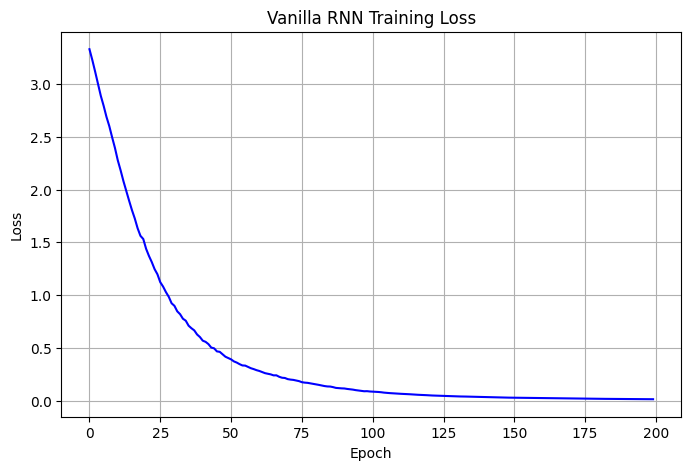

In [15]:
plt.figure(figsize=(8,5))

plt.plot(rnn_history.history['loss'], color='blue')

plt.title("Vanilla RNN Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

## Observation

The loss should gradually decrease as training progresses. Since this is a simple recurrent neural network, it learns basic sentence patterns, but it may not perform well on long-term dependencies.

## Model 2: LSTM

Long Short-Term Memory (LSTM) is an improved version of the traditional RNN. It contains memory cells and gates that help the network remember important information for a longer period of time. This makes LSTM more effective for text generation and sequence prediction tasks.

In [16]:
lstm_model = Sequential([
    Embedding(input_dim=total_words,
              output_dim=64),

    LSTM(128),

    Dense(total_words, activation='softmax')
])

## Compile the LSTM Model

The LSTM model is compiled using the Adam optimizer and Sparse Categorical Crossentropy loss function.

In [17]:
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train the LSTM Model

The model is trained for 200 epochs using the prepared training dataset.

In [19]:
lstm_history = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.0143 - loss: 4.2057
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1000 - loss: 4.1955
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1286 - loss: 4.1877
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1286 - loss: 4.1789
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0857 - loss: 4.1681
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1000 - loss: 4.1516
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0571 - loss: 4.1261
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0429 - loss: 4.0866
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0429 - loss: 4.0226
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0429 - loss: 3.9841
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.0429 - loss: 3.9711
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0571 - lo

In [20]:
print("Final Training Loss :", lstm_history.history['loss'][-1])

print("Final Training Accuracy :", lstm_history.history['accuracy'][-1])

Final Training Loss : 0.14532527327537537
Final Training Accuracy : 1.0


## Model 3: GRU

The Gated Recurrent Unit (GRU) is another recurrent neural network architecture. It is simpler than LSTM because it uses fewer gates while still maintaining good performance on sequence learning tasks.

In [21]:
gru_model = Sequential([
    Embedding(input_dim=total_words,
              output_dim=64),

    GRU(128),

    Dense(total_words, activation='softmax')
])

## Compile the GRU Model

In [22]:
gru_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
gru_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train the GRU Model

In [24]:
gru_history = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.0000e+00 - loss: 4.2064
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1000 - loss: 4.1913
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1714 - loss: 4.1794
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2571 - loss: 4.1666
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2143 - loss: 4.1532
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1714 - loss: 4.1360
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1714 - loss: 4.1145
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1143 - loss: 4.0847
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0857 - loss: 4.0470
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0571 - loss: 3.9886
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0429 - loss: 3.9132
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0429 

In [25]:
print("Final Training Loss :", gru_history.history['loss'][-1])

print("Final Training Accuracy :", gru_history.history['accuracy'][-1])

Final Training Loss : 0.02931201085448265
Final Training Accuracy : 1.0


## Compare Training Loss

To compare the learning performance of all three models, I plotted the training loss against the number of epochs.

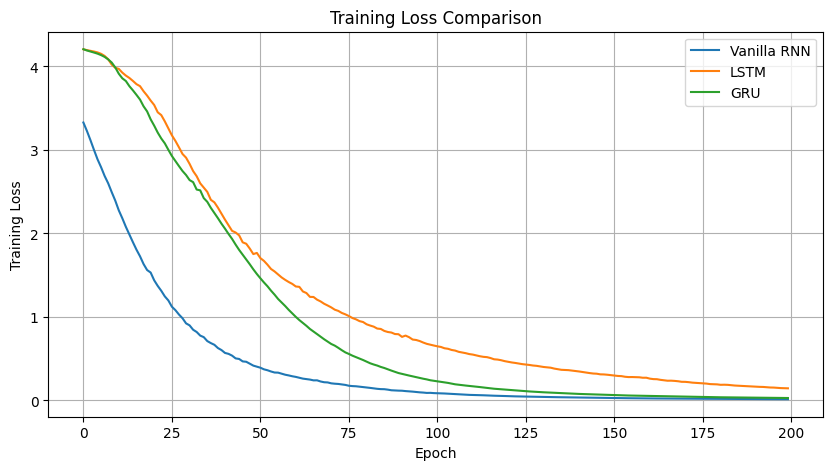

In [26]:
plt.figure(figsize=(10,5))

plt.plot(rnn_history.history['loss'], label='Vanilla RNN')

plt.plot(lstm_history.history['loss'], label='LSTM')

plt.plot(gru_history.history['loss'], label='GRU')

plt.xlabel("Epoch")

plt.ylabel("Training Loss")

plt.title("Training Loss Comparison")

plt.legend()

plt.grid(True)

plt.show()

## Text Generation Function

This function predicts one word at a time using the trained model. The predicted word is added to the input sentence, and the process is repeated until the required number of words is generated.

In [27]:
def generate_text(model, seed_text, next_words=10):

    for i in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = tokenizer.index_word.get(predicted, "")

        seed_text += " " + output_word

    return seed_text

# 1. Generate Text using Vanilla RNN
# 2. Generate Text using LSTM
# 3. Generate Text using GRU

In [28]:
print(generate_text(rnn_model, "deep learning", 10))

deep learning helps machines learn from large amounts of data are trained


In [29]:
print(generate_text(lstm_model, "deep learning", 10))

deep learning helps machines learn from large amounts of data data data


In [30]:
print(generate_text(gru_model, "deep learning", 10))

deep learning helps machines learn from large amounts of data data similar


## Compare Final Loss Values

In [31]:
print("Vanilla RNN Loss :", rnn_history.history['loss'][-1])

print("LSTM Loss :", lstm_history.history['loss'][-1])

print("GRU Loss :", gru_history.history['loss'][-1])

Vanilla RNN Loss : 0.014765952713787556
LSTM Loss : 0.14532527327537537
GRU Loss : 0.02931201085448265


# Conclusion

In this project, I implemented three different recurrent neural network models for text generation: Vanilla RNN, LSTM, and GRU.

The models were trained on the same text corpus so that their performance could be compared fairly. The Vanilla RNN was able to learn simple sentence patterns but had difficulty remembering long sequences. LSTM performed better because it uses memory cells and gates to preserve important information over time. GRU also generated meaningful text and trained faster than LSTM because it has a simpler architecture.

Overall, I observed that LSTM and GRU produced better text than the Vanilla RNN. This project helped me understand sequence modeling, next-word prediction, and the advantages of gated recurrent neural networks.